# Logistic Regression with Manual Neural Network

a 1-layer neural network (logistic regression) with sigmoid activation


In [1]:
import autograd.numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

# Import helper code from the provided modules
from activations import sigmoid, sigmoid_der
from functions import create_layers_batch, feed_forward_batch
from costs import binary_cross_entropy_loss, binary_cross_entropy_der
from sklearn.metrics import roc_curve, roc_auc_score

from train_funct import train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM  

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score


## 1. Load the data

In [2]:
# Load the heart disease dataset
df = pd.read_csv("../Data/heart.csv")

print(df.shape)
df.head()

(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. Data preparation

In [3]:
# Separate features and target
target_col = "HeartDisease"
X = df.drop(columns=[target_col])
y = df[target_col]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X_encoded.shape)
X_encoded.head()

Encoded feature shape: (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


In [4]:
# Train–test split (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (642, 15)
Test shape: (276, 15)


## 3. Prepare data for the manual neural network

In [5]:
# Convert to autograd / numpy arrays
inputs_train = np.array(X_train_scaled)
inputs_test = np.array(X_test_scaled)

# Targets must be column vectors (n, 1)
targets_train = y_train.values.reshape(-1, 1).astype(float)
targets_test = y_test.values.reshape(-1, 1).astype(float)

n_features = inputs_train.shape[1]
print("Number of features:", n_features)

Number of features: 15


## 4. Define logistic regression model using the manual NN code

We create a 1-layer network:

- Input size = number of features
- Output size = 1
- Activation = sigmoid

In [6]:
# Network architecture: logistic regression (1-layer NN)
network_input_size = n_features
layer_output_sizes = [1]  # single neuron for binary classification

activation_funcs = [sigmoid]
activation_ders = [sigmoid_der]

# Create initial random weights & biases
layers = create_layers_batch(network_input_size, layer_output_sizes)


# Check initial loss
init_pred = feed_forward_batch(inputs_train, layers, activation_funcs)
init_loss_raw = binary_cross_entropy_loss(init_pred, targets_train)
init_loss = -init_loss_raw  # binary_cross_entropy_loss returns negative of standard sign
print(f"Initial BCE loss: {init_loss:.4f}")

Initial BCE loss: 1.0026


## 5. Trial Train the model with Adam

In [7]:
learning_rate = 0.01
epochs = 500

predictions_history, last_prediction, trained_layers = train_network_ADAM(
    inputs_train,
    layers,
    activation_funcs,
    targets_train,
    activation_ders,
    learning_rate=learning_rate,
    epochs=epochs,
    cost_der=binary_cross_entropy_der,
    grad_tol=1e-8,
    verbose=False,
)

final_loss_raw = binary_cross_entropy_loss(last_prediction, targets_train)
final_loss = -final_loss_raw
print(f"Final training BCE loss: {final_loss:.4f}")

Final training BCE loss: 0.3412


### Training loss curve

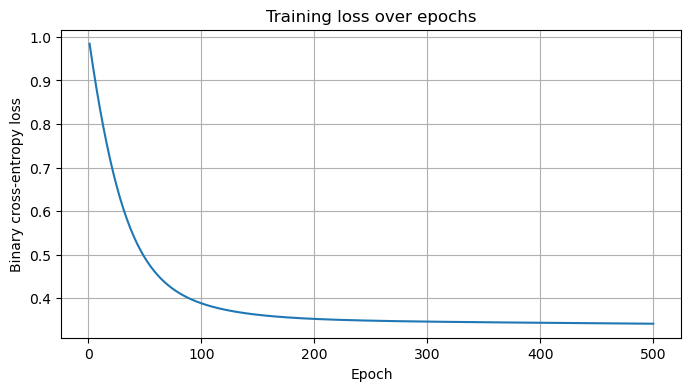

In [8]:
# Compute loss per epoch for plotting
losses = []
for pred in predictions_history:
    loss_raw = binary_cross_entropy_loss(pred, targets_train)
    losses.append(-loss_raw)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss over epochs")
plt.grid(True)
plt.show()

## 6. Evaluate the model

In [9]:
# Training predictions
train_probs = last_prediction
train_preds = (train_probs >= 0.5).astype(int)

# Test predictions
test_probs = feed_forward_batch(inputs_test, trained_layers, activation_funcs)
test_preds = (test_probs >= 0.5).astype(int)

# Accuracy
train_acc = accuracy_score(targets_train, train_preds)
test_acc = accuracy_score(targets_test, test_preds)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}")

Train accuracy: 0.846
Test  accuracy: 0.859


In [10]:
print("Classification report (test set):")
print(classification_report(targets_test, test_preds))

print("Confusion matrix (test set):")
print(confusion_matrix(targets_test, test_preds))

Classification report (test set):
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84       123
         1.0       0.87      0.88      0.87       153

    accuracy                           0.86       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276

Confusion matrix (test set):
[[102  21]
 [ 18 135]]


## Print confusion matrix as fig

In [11]:
def plot_confusion_matrix(cm, title="", class_names=("No CVD", "CVD"), cmap="set3"):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap=cmap)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Count", rotation=270, labelpad=15)

    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


## 7. Grid search over learning rate

In [12]:
# Same learning rates as before
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]   # e.g. 1e-4 ... ~3e-1

In [13]:
def grid_search_lr_for_trainer(trainer_func, trainer_name, learning_rates, epochs=300, **trainer_extra_kwargs):
    """
    Runs a learning-rate grid search for a given trainer function,
    plots train vs test accuracy, and also plots a ROC curve for the
    best learning rate (by test accuracy). Additionally prints
    confusion matrix, accuracy, precision, recall, and F1-score for the
    best learning rate model on the test set.

    Returns:
        lrs, train_accs, test_accs, best_lr, best_test_acc
    """
    results = []

    best_lr = None
    best_test_acc = -np.inf

    for lr in learning_rates:
        # Fresh initialization for each learning rate
        layers_init = create_layers_batch(network_input_size, layer_output_sizes)

        preds_hist, last_pred, layers_trained = trainer_func(
            inputs_train,
            layers_init,
            activation_funcs,
            targets_train,
            activation_ders,
            learning_rate=lr,
            epochs=epochs,
            cost_der=binary_cross_entropy_der,
            **trainer_extra_kwargs,
        )

        # ---- Train accuracy ----
        train_preds = (last_pred >= 0.5).astype(int)
        train_acc = accuracy_score(targets_train, train_preds)

        # ---- Test accuracy ----
        test_probs = feed_forward_batch(inputs_test, layers_trained, activation_funcs)
        test_preds = (test_probs >= 0.5).astype(int)
        test_acc = accuracy_score(targets_test, test_preds)

        results.append((lr, train_acc, test_acc))
        print(f"[{trainer_name}] lr={lr:.5f} -> train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

        # Track best LR by test accuracy
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_lr = lr

    # Convert to arrays for plotting
    lrs        = np.array([r[0] for r in results])
    train_accs = np.array([r[1] for r in results])
    test_accs  = np.array([r[2] for r in results])

    # ---- Plot: train vs test accuracy vs LR ----
    plt.figure(figsize=(8, 4))
    plt.xscale("log")

    plt.plot(lrs, train_accs, marker="o", label="Train Accuracy")
    plt.plot(lrs, test_accs, marker="s", label="Test Accuracy")

    plt.xlabel("Learning rate (log scale)")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Rate Grid Search – {trainer_name}")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

    print(f"\nBest LR for {trainer_name} by test accuracy: {best_lr:.5g} (test_acc = {best_test_acc:.3f})")

    # ============================================================
    # Retrain with best_lr, then compute metrics + ROC
    # ============================================================
    layers_init = create_layers_batch(network_input_size, layer_output_sizes)
    _, last_pred_best, layers_trained_best = trainer_func(
        inputs_train,
        layers_init,
        activation_funcs,
        targets_train,
        activation_ders,
        learning_rate=best_lr,
        epochs=epochs,
        cost_der=binary_cross_entropy_der,
        **trainer_extra_kwargs,
    )

    test_probs_best = feed_forward_batch(inputs_test, layers_trained_best, activation_funcs)

    # Flatten targets and probabilities for sklearn
    y_true = targets_test.ravel()
    y_score = test_probs_best.ravel()

    # ---- Thresholded predictions for classification metrics ----
    y_pred = (y_score >= 0.5).astype(int)

    # ---- Confusion matrix + metrics ----
    cm = confusion_matrix(y_true, y_pred)

    
    # ---- Accuracy, Precision, Recall , F1
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\n=== Test metrics for best LR ===")
    print(f"Trainer: {trainer_name}")
    print(f"Best LR: {best_lr:.5g}")
    print("Confusion matrix [ [TN FP]\n                 [FN TP] ]:")
    print(cm)# keep for controll
    
    #---- plot confusion matrix As fig.
    plot_confusion_matrix(cm, cmap="tab20")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # ---- ROC + AUC ----
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel("True Positive Rate", fontsize=16)
    plt.title(f"ROC Curve – {trainer_name} (best LR = {best_lr:.5g})")
    
    # Legend: bottom-right with larger font
    plt.legend(
        loc="lower right",
        fontsize=14,
        frameon=True
    )
    
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


    return lrs, train_accs, test_accs, best_lr, best_test_acc


## Model with plain gradient discend 

[Plain GD] lr=0.00010 -> train_acc=0.553, test_acc=0.547
[Plain GD] lr=0.00100 -> train_acc=0.553, test_acc=0.547
[Plain GD] lr=0.01000 -> train_acc=0.555, test_acc=0.547
[Plain GD] lr=0.10000 -> train_acc=0.562, test_acc=0.554


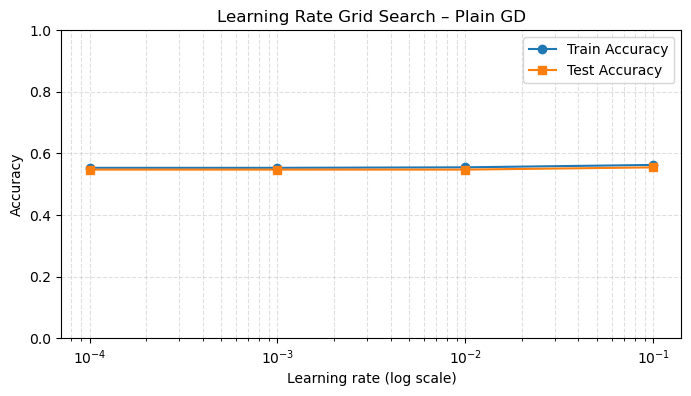


Best LR for Plain GD by test accuracy: 0.1 (test_acc = 0.554)

=== Test metrics for best LR ===
Trainer: Plain GD
Best LR: 0.1
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[81 42]
 [81 72]]


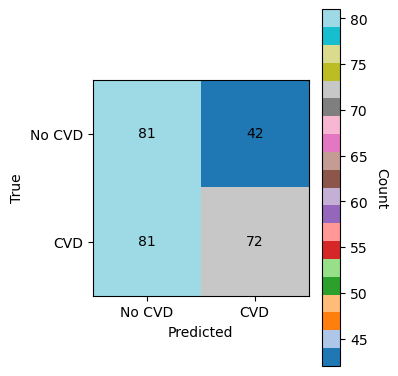

Accuracy : 0.5543
Precision: 0.6316
Recall   : 0.4706
F1-score : 0.5393


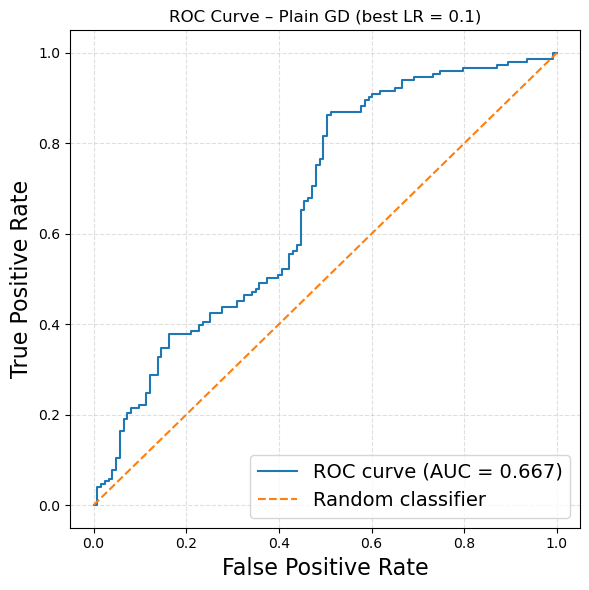

In [14]:
lrs_gd, train_accs_gd, test_accs_gd, best_lr_gd, best_test_acc_gd = grid_search_lr_for_trainer(
    trainer_func=train_network,
    trainer_name="Plain GD",
    learning_rates=learning_rates,
    epochs=300,
)

## Model with SGD 

[SGD + Momentum] lr=0.00010 -> train_acc=0.553, test_acc=0.547
[SGD + Momentum] lr=0.00100 -> train_acc=0.555, test_acc=0.547
[SGD + Momentum] lr=0.01000 -> train_acc=0.562, test_acc=0.554
[SGD + Momentum] lr=0.10000 -> train_acc=0.614, test_acc=0.612


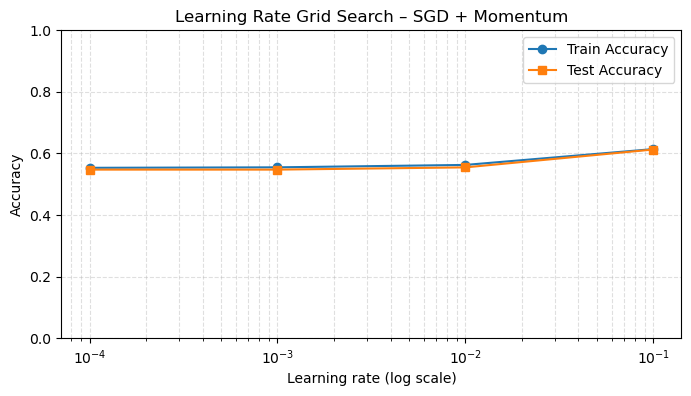


Best LR for SGD + Momentum by test accuracy: 0.1 (test_acc = 0.612)

=== Test metrics for best LR ===
Trainer: SGD + Momentum
Best LR: 0.1
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[90 33]
 [74 79]]


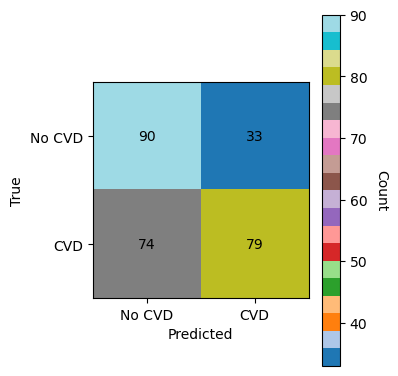

Accuracy : 0.6123
Precision: 0.7054
Recall   : 0.5163
F1-score : 0.5962


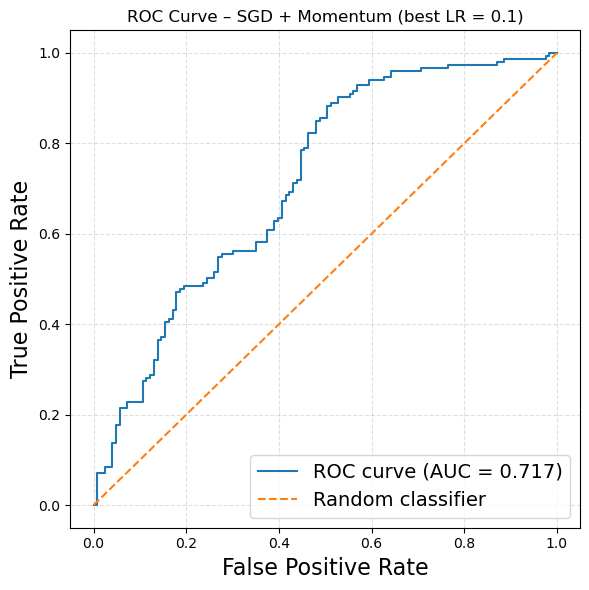

In [15]:
lrs_gd, train_accs_gd, test_accs_gd, best_lr_gd, best_test_acc_gd = grid_search_lr_for_trainer(
    trainer_func=train_network_SGD_momentum,
    trainer_name="SGD + Momentum",
    learning_rates=learning_rates,
    epochs=300,
    momentum=0.9, 
    # train_network_SGD_momentum(..., learning_rate=0.001, momentum=0.8, epochs=30, cost_der=mse_der)
)


## Model with RMSprop

[RMSprop] lr=0.00010 -> train_acc=0.575, test_acc=0.572
[RMSprop] lr=0.00100 -> train_acc=0.754, test_acc=0.757
[RMSprop] lr=0.01000 -> train_acc=0.852, test_acc=0.880
[RMSprop] lr=0.10000 -> train_acc=0.855, test_acc=0.870


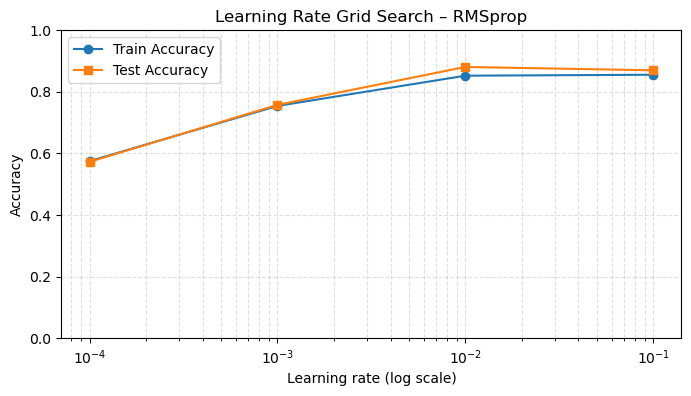


Best LR for RMSprop by test accuracy: 0.01 (test_acc = 0.880)

=== Test metrics for best LR ===
Trainer: RMSprop
Best LR: 0.01
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[103  20]
 [ 13 140]]


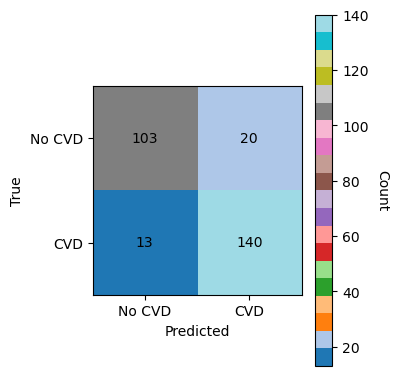

Accuracy : 0.8804
Precision: 0.8750
Recall   : 0.9150
F1-score : 0.8946


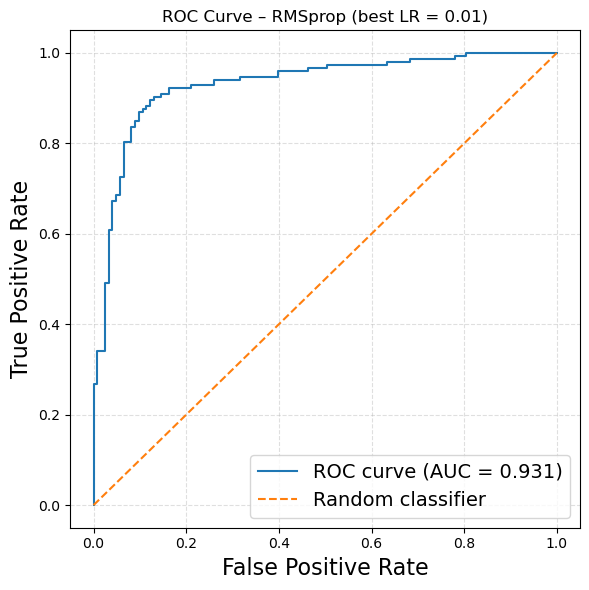

In [16]:
lrs_gd, train_accs_gd, test_accs_gd, best_lr_gd, best_test_acc_gd = grid_search_lr_for_trainer(
    trainer_func=train_network_RMSprop,
    trainer_name="RMSprop",
    learning_rates=learning_rates,
    epochs=300,
    rho=0.9,
    eps=1e-8,
    grad_tol=1e-8,
    verbose=False,
    # Signature:
    # train_network_RMSprop(..., learning_rate=0.001, rho=0.9, eps=1e-8,
    #                       epochs=30, grad_tol=1e-6, verbose=False, cost_der=mse_der)
)


## Model with Adam

[Adam] lr=0.00010 -> train_acc=0.573, test_acc=0.572
[Adam] lr=0.00100 -> train_acc=0.741, test_acc=0.736
[Adam] lr=0.01000 -> train_acc=0.841, test_acc=0.859
[Adam] lr=0.10000 -> train_acc=0.850, test_acc=0.884


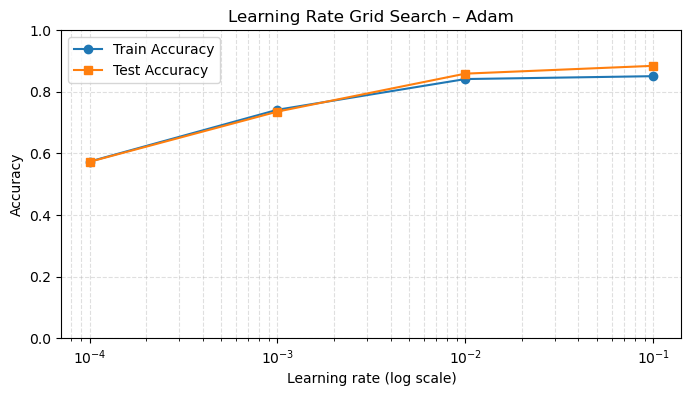


Best LR for Adam by test accuracy: 0.1 (test_acc = 0.884)

=== Test metrics for best LR ===
Trainer: Adam
Best LR: 0.1
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[103  20]
 [ 12 141]]


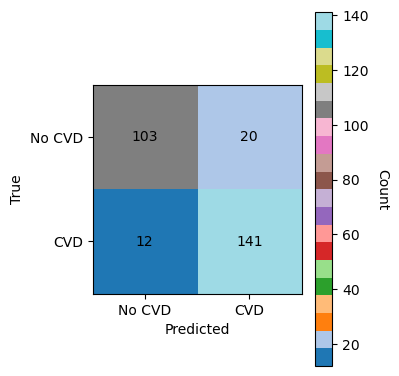

Accuracy : 0.8841
Precision: 0.8758
Recall   : 0.9216
F1-score : 0.8981


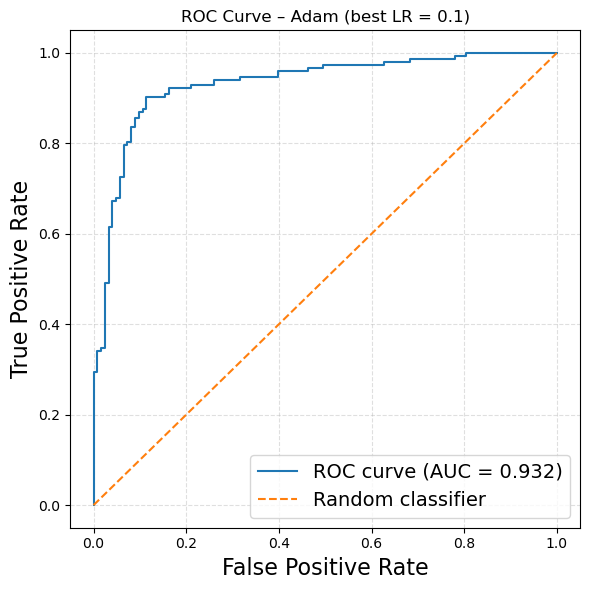

In [17]:
lrs_gd, train_accs_gd, test_accs_gd, best_lr_gd, best_test_acc_gd = grid_search_lr_for_trainer(
    trainer_func=train_network_ADAM,
    trainer_name="Adam",
    learning_rates=learning_rates,
    epochs=300,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    grad_tol=1e-8,
    verbose=False,
)
